# BaseAL Embedding Visualisation Example

This notebook demonstrates how to use the updated API:

```python
visualize_embeddings(dataset_path, idxes, with_label)
```

The meaning of `idxes` is:
- `idxes` is a 0-based array of sample indices **after matching available embeddings**
- In other words, rows in `labels.csv` without a corresponding embedding file are removed first, and the remaining samples are then re-indexed
- `idxes=None` means all matchable samples are used
- `idxes` must be a 1D integer array with no duplicates and no out-of-range values

Dataset root requirements:
- Must contain `labels.csv`
- Must contain `embeddings/<model_name>/*.npy`
- Files are matched using `Path(filename).stem + f"_{model_name}.npy"`


In [1]:
from pathlib import Path
import sys
import numpy as np

PROJECT_ROOT = Path("/scratch/asignal/shiqi/Project/BaseAL")  # Change this to your actual project root path

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from core.utils.visualization import visualize_embeddings


core.active_learner - INFO - Pre-warming UMAP (triggering numba JIT compilation)...
core.active_learner - INFO - UMAP pre-warming completed in 6.4404542446136475


## What Is In the Returned Object

`visualize_embeddings(...)` returns a `VisualizationResult`. Common fields include:
- `viz.idxes`: the matched-sample indices actually used in this run
- `viz.annotations`: the corresponding annotation table
- `viz.embeddings`: the original embedding matrix
- `viz.coordinates`: the 2D dimensionality-reduction result
- `viz.labels`: a 1D integer array for single-label data, or a binary matrix for multi-label data
- `viz.label_names`: human-readable label strings for each sample
- `viz.label_indices_for_color`: the primary label index used for coloring each sample
- `viz.class_names`: the list of class names for the full dataset
- `viz.figure`, `viz.axes`: matplotlib objects


Used idxes shape: (200,)
First 10 idxes: [0 1 2 3 4 5 6 7 8 9]
Reduction steps: ('StandardScaler', 'PCA(64)', 'UMAP(2)')
Coordinates shape: (200, 2)
Embeddings shape: (200, 1024)
Labels shape: (200,)
Is multilabel: False
Classes: ['chainsaw', 'clock_tick', 'crackling_fire', 'crying_baby', 'dog', 'helicopter', 'rain', 'rooster', 'sea_waves', 'sneezing']


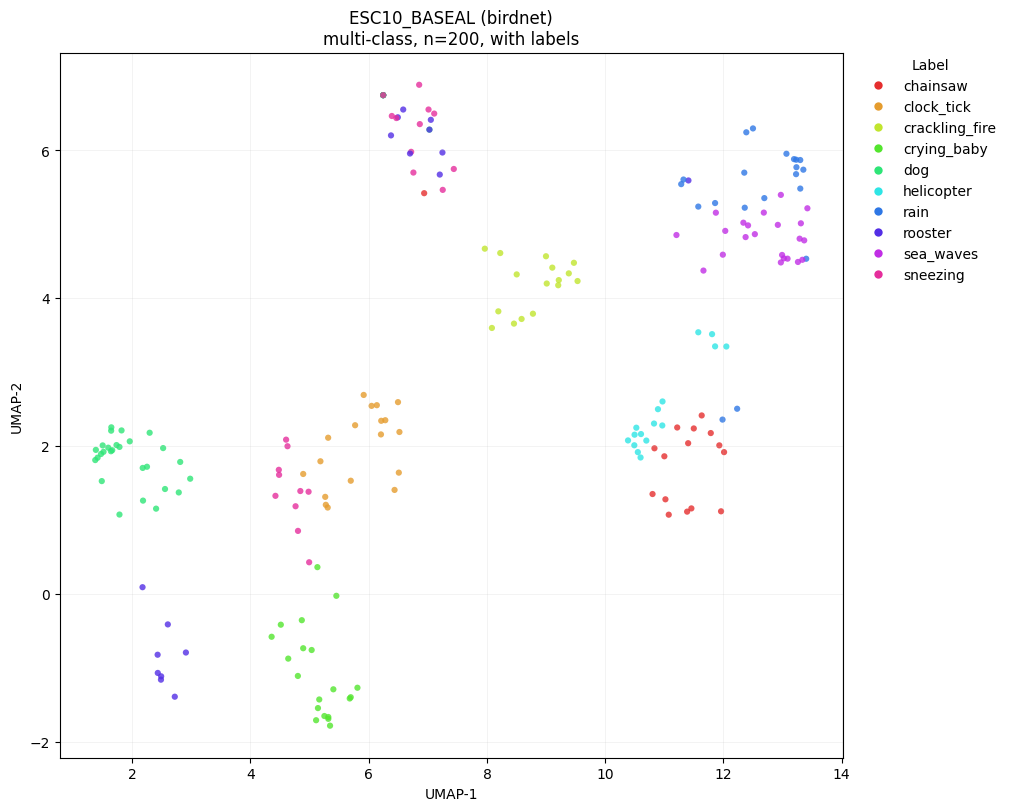

In [2]:
# Single-label example: ESC10
multi_class_ds_path = PROJECT_ROOT / "ESC10_BASEAL"  # Change this to your actual dataset path
multi_class_ds_idxes = np.arange(200, dtype=np.int64)

viz_single = visualize_embeddings(
    dataset_path=multi_class_ds_path,
    idxes=multi_class_ds_idxes,
    with_label=True,
    max_reference_samples=500,
)

print("Used idxes shape:", viz_single.idxes.shape)
print("First 10 idxes:", viz_single.idxes[:10])
print("Reduction steps:", viz_single.reduction_steps)
print("Coordinates shape:", viz_single.coordinates.shape)
print("Embeddings shape:", viz_single.embeddings.shape)
print("Labels shape:", viz_single.labels.shape)
print("Is multilabel:", viz_single.is_multilabel)
print("Classes:", viz_single.class_names)

In [3]:
viz_single.annotations[["matched_index", "annotation_index", "filename", "label"]].head(10)


,matched_index,annotation_index,filename,label
0,0,0,1-100032-A-0_000_003.mp3,dog
1,1,1,1-100032-A-0_003_006.mp3,dog
2,2,2,1-110389-A-0_000_003.mp3,dog
3,3,3,1-110389-A-0_003_006.mp3,dog
4,4,4,1-116765-A-41_000_003.mp3,chainsaw
5,5,5,1-116765-A-41_003_006.mp3,chainsaw
6,6,6,1-17150-A-12_000_003.mp3,crackling_fire
7,7,7,1-17150-A-12_003_006.mp3,crackling_fire
8,8,8,1-172649-A-40_000_003.mp3,helicopter
9,9,9,1-172649-A-40_003_006.mp3,helicopter


## How Multi-Label Samples Are Handled

For samples whose `label` column looks like `"a;b;c"`, the utility will:
- Convert each sample into a binary label vector stored in `viz.labels`
- Join all active labels into a readable string stored in `viz.label_names`
- Generate an additional primary-label index `viz.label_indices_for_color` for scatter coloring

Note: the primary label is the **first active class** in the sample's binary vector, meaning the active class with the smallest index after `viz.class_names` ordering. This matches the current BaseAL API coloring semantics.

Default coloring logic:
- Only consider classes that actually appear in the current plot
- Assign colors to those present classes evenly on a fixed color wheel
- `no_call` / `noise` / `negative` are treated like normal classes by default and are not automatically colored gray


Used idxes: [108255 376508 457954 213748 413446 326005 255998 435416 166855 479719
  82088 335636 273574 283351 452117 454974 199822 229432 330775 254456
  83053 285088 326056 467559 305658 290014  29791 352601  69531  41308
 478630 446922 345519 191001 181203 419231 326967 165916 256164 305039
 403995 163090 316388  11097 332274  51742 340013 126673 458596 487960
  10988 128379 345600 432275   9472 258919 317364 411896 200009 287751
 408817 103893 337188 331640 476181 172979 269394 156554 141099 175008
 468514  65151 405024 199918 176254 373489 410615 497611  14178 362933
 164170 209432 217139 282213 254159  72776 325712 192575 303319 141757
 383852 212781 147774 244520 296722  80519  91178 246622 277024  30674
 363259  80489 160828  69263 402316 175612 410596 444843 364380 479196
 414151 338478 493573 206044 227666  86666 264800    888 387096 410160
 153556 488030 406993  74086 444373 331813 359242 349594 451381 201872
 479462 255758 114406 404472  13690 313917 442161 209081 268342  

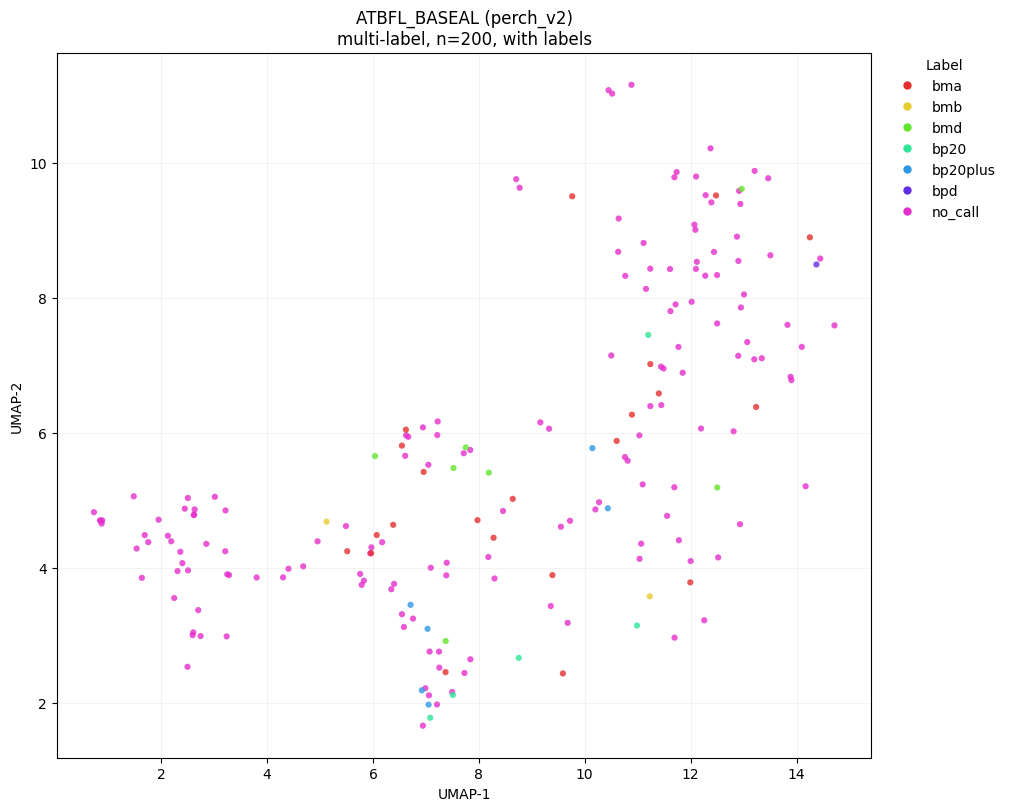

In [4]:
# Multi-label example: ATBFL
# You can also replace this with HSN:
import os
multi_label_ds_path = Path(os.getenv("LOCAL_SCRATCH")) / "ATBFL_BASEAL"  # Change this to your actual dataset path
multi_label_ds_idxes = np.random.choice(500000, size=200, replace=False)

viz_multi = visualize_embeddings(
    dataset_path=multi_label_ds_path,
    idxes=multi_label_ds_idxes,
    with_label=True,
)

print("Used idxes:", viz_multi.idxes)
print("Reduction steps:", viz_multi.reduction_steps)
print("Coordinates shape:", viz_multi.coordinates.shape)
print("Embeddings shape:", viz_multi.embeddings.shape)
print("Labels shape:", viz_multi.labels.shape)
print("Is multilabel:", viz_multi.is_multilabel)
print("First 10 class names:", viz_multi.class_names[:10])

In [5]:
import pandas as pd

inspect_df = viz_multi.annotations[["matched_index", "annotation_index", "filename", "label"]].copy()
inspect_df["rendered_label_names"] = viz_multi.label_names
inspect_df["color_label_index"] = viz_multi.label_indices_for_color
inspect_df["color_label_name"] = [
    viz_multi.class_names[idx] for idx in viz_multi.label_indices_for_color
]

inspect_df


,matched_index,annotation_index,filename,label,rendered_label_names,color_label_index,color_label_name
0,108255,108255,casey2014__2014-06-05T12-00-00_000_1145_1150.wav,no_call,no_call,7,no_call
1,376508,376508,elephantisland2014__2014-05-13T09-00-00_000_02...,bp20,bp20,4,bp20
2,457954,457954,kerguelen2005__2005-07-22T22-00-00_000_0110_01...,no_call,no_call,7,no_call
3,213748,213748,elephantisland2013__2013-03-09T09-00-00_000_01...,no_call,no_call,7,no_call
4,413446,413446,kerguelen2005__2005-03-01T19-00-00_000_1080_10...,no_call,no_call,7,no_call
...,...,...,...,...,...,...,...
195,492921,492921,kerguelen2005__2006-01-15T02-00-00_000_1905_19...,no_call,no_call,7,no_call
196,77902,77902,casey2014__2014-03-20T20-00-00_000_0790_0795.wav,no_call,no_call,7,no_call
197,208971,208971,elephantisland2013__2013-03-03T16-00-00_000_02...,no_call,no_call,7,no_call
198,305962,305962,elephantisland2014__2014-07-06T22-00-00_000_00...,bma,bma,0,bma


## If You Want to Force Negative Samples to Gray

The example below redraws `no_call` / `noise` / `negative` in gray, while keeping the default behavior for other classes: evenly assigning colors only across classes that actually appear in the current plot.

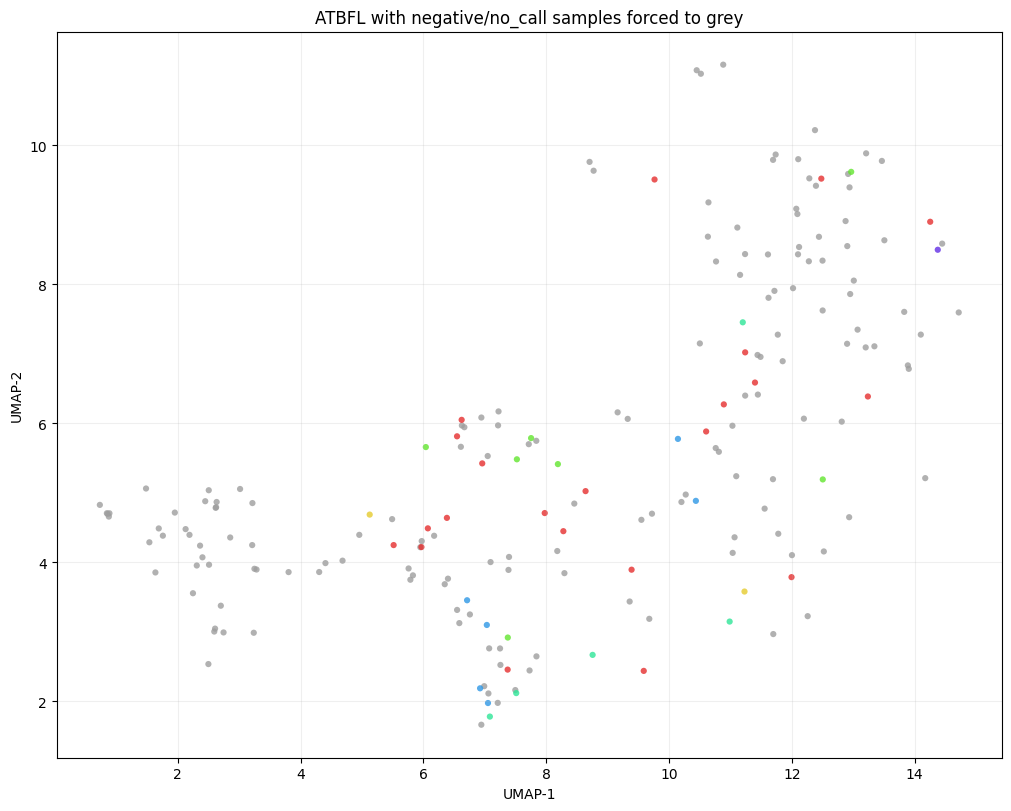

In [6]:
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb

negative_labels = {"no_call", "noise", "negative"}
present_indices = np.unique(viz_multi.label_indices_for_color)

if len(present_indices) == 1:
    hues = np.array([2.0 / 3.0], dtype=np.float32)
else:
    hues = np.linspace(0.0, 1.0, len(present_indices), endpoint=False, dtype=np.float32)

rgb = hsv_to_rgb(
    np.column_stack([
        hues,
        np.full(len(present_indices), 0.8, dtype=np.float32),
        np.full(len(present_indices), 0.9, dtype=np.float32),
    ])
)
class_color_lookup = {
    int(class_idx): rgb[pos] for pos, class_idx in enumerate(present_indices)
}

point_colors = []
for class_idx in viz_multi.label_indices_for_color:
    class_name = viz_multi.class_names[class_idx]
    if class_name in negative_labels:
        point_colors.append("#9E9E9E")
    else:
        point_colors.append(class_color_lookup[int(class_idx)])

fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
ax.scatter(
    viz_multi.coordinates[:, 0],
    viz_multi.coordinates[:, 1],
    c=point_colors,
    s=20,
    alpha=0.8,
    linewidths=0,
)
ax.set_title("ATBFL with negative/no_call samples forced to grey")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.grid(alpha=0.2)
plt.show()
